# MSE 433 Module 4 — Medical Procedure Case Analysis

This notebook covers:

- **Phase 1: Data and Discovery**
- **Phase 2: Modeling and Validation**

The goal is to analyze procedural performance, variability, physician differences, and case complexity using the provided dataset.


## 1. Setup

Import the libraries needed for data cleaning, analysis, visualization, and modeling.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 2. Load and Clean the Data

The Excel file has a title row and a two-row header. This cell reconstructs the proper column names and prepares the dataset for analysis.


In [28]:
file_path = "../data/MSE433_M4_Data.xlsx"

raw = pd.read_excel(file_path, header=None)

# Build headers from rows 2 and 3
hdr1 = raw.iloc[2].fillna("")
hdr2 = raw.iloc[3].fillna("")

headers = []
for a, b in zip(hdr1, hdr2):
    a = str(a).strip()
    b = str(b).strip()
    if a == "" and b == "":
        headers.append("")
    elif b != "":
        headers.append(f"{a} {b}".strip())
    else:
        headers.append(a)

# Actual data starts at row 4
df = raw.iloc[4:].copy()
df.columns = headers
df = df.loc[:, df.columns != ""].copy()

# Convert data types
for col in df.columns:
    if col not in ["DATE", "PHYSICIAN", "PT OUT TIME", "Note"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

# Helper variables
CASE_TIME = "CASE TIME (Cath In-Out)"
df["complex_case"] = df["Note"].notna() & (df["Note"].astype(str).str.strip() != "")
df["month"] = df["DATE"].dt.month

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
for c in df.columns:
    print("-", c)


Shape: (150, 23)


,CASE #,DATE,PHYSICIAN,PT PREP/INTUBATION Pt-In-Access,ACCESSS (Min),TSP (Min),PRE-MAP (Min),ABL DURATION (Abl Start-End),ABL TIME (Min),#ABL,#APPLICATIONS 3/Abl,LA DWELL TIME (Abl Start-Cath-Out),CASE TIME (Cath In-Out),AVG CASE TIME (Min),SKIN-SKIN (Access to Cath-Out),AVG SKIN-SKIN (Min),POST CARE/EXTUBATION (Cath-Out to Pt-Out),AVG TURNOVER TIME (Min),PT OUT TIME,PT IN-OUT (Min),Note,complex_case,month
4,1,2025-01-13,Dr. A,19.0,6.0,10.0,2.0,28.0,7.35,21.0,63.0,31.0,50.0,NaN,56.0,NaN,17.0,NaN,NaN,92.0,NaN,False,1.0
5,2,2025-01-14,Dr. A,24.0,3.0,7.0,2.0,25.0,6.65,19.0,57.0,29.0,47.0,NaN,50.0,NaN,12.0,NaN,NaN,86.0,NaN,False,1.0
6,3,2025-01-14,Dr. A,22.0,5.0,12.0,2.0,41.0,8.40,24.0,72.0,43.0,37.0,NaN,42.0,NaN,12.0,NaN,NaN,94.0,NaN,False,1.0
7,4,2025-01-20,Dr. B,48.0,5.0,37.0,2.0,41.0,7.35,21.0,63.0,54.0,91.0,NaN,96.0,NaN,20.0,NaN,NaN,164.0,NaN,False,1.0
8,5,2025-01-20,Dr. B,25.0,5.0,16.0,2.0,33.0,7.70,22.0,66.0,33.0,49.0,NaN,54.0,NaN,19.0,NaN,NaN,98.0,NaN,False,1.0



Columns:
- CASE #
- DATE
- PHYSICIAN
- PT PREP/INTUBATION Pt-In-Access
- ACCESSS (Min)
- TSP (Min)
- PRE-MAP (Min)
- ABL DURATION (Abl Start-End)
- ABL TIME (Min)
- #ABL
- #APPLICATIONS 3/Abl
- LA DWELL TIME (Abl Start-Cath-Out)
- CASE TIME (Cath In-Out)
- AVG CASE TIME (Min)
- SKIN-SKIN (Access to Cath-Out)
- AVG SKIN-SKIN (Min)
- POST CARE/EXTUBATION (Cath-Out to Pt-Out)
- AVG TURNOVER TIME (Min)
- PT OUT TIME
- PT IN-OUT (Min)
- Note
- complex_case
- month


## 3. Quick Data Quality Check

Before starting the analysis, check missing values and basic structure.


In [29]:
missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary.to_frame("missing_values"))

print("\nPhysicians in dataset:", sorted(df["PHYSICIAN"].dropna().unique()))
print("Date range:", df["DATE"].min(), "to", df["DATE"].max())


,missing_values
AVG TURNOVER TIME (Min),144
AVG CASE TIME (Min),133
AVG SKIN-SKIN (Min),133
Note,126
PT OUT TIME,96
POST CARE/EXTUBATION (Cath-Out to Pt-Out),6
TSP (Min),5
SKIN-SKIN (Access to Cath-Out),5
CASE TIME (Cath In-Out),5
LA DWELL TIME (Abl Start-Cath-Out),5



Physicians in dataset: ['Dr. A', 'Dr. B', 'Dr. C']
Date range: 2025-01-13 00:00:00 to 2025-10-08 00:00:00


# Phase 1 — Data and Discovery

This phase focuses on understanding performance, variability, physician differences, and case complexity.


## 4. Performance and Variability

Use **CASE TIME** as the main performance metric.


In [30]:
summary_stats = df[CASE_TIME].describe()
std_case_time = df[CASE_TIME].std()
iqr_case_time = df[CASE_TIME].quantile(0.75) - df[CASE_TIME].quantile(0.25)

print("CASE TIME Summary Statistics")
display(summary_stats.to_frame("value"))
print(f"Standard deviation: {std_case_time:.2f}")
print(f"IQR: {iqr_case_time:.2f}")


CASE TIME Summary Statistics


,value
count,145.000000
mean,40.731034
std,17.385441
min,17.000000
25%,30.000000
50%,37.000000
75%,45.000000
max,159.000000


Standard deviation: 17.39
IQR: 15.00


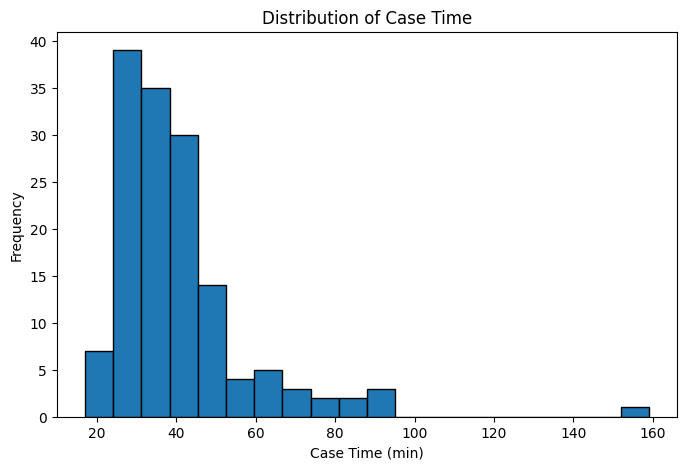

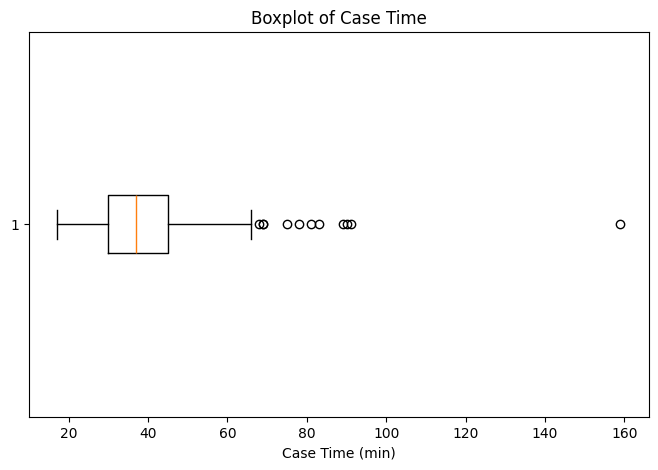

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(df[CASE_TIME].dropna(), bins=20, edgecolor="black")
plt.xlabel("Case Time (min)")
plt.ylabel("Frequency")
plt.title("Distribution of Case Time")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df[CASE_TIME].dropna(), vert=False)
plt.xlabel("Case Time (min)")
plt.title("Boxplot of Case Time")
plt.show()


### Interpretation

Use this section after running the code:
- Identify the average and median case time
- Comment on whether variability is high
- Note whether there are outliers or extreme cases


## 5. Differences Across Physicians

Compare average performance and variability across physicians.


In [32]:
physician_summary = (
    df.groupby("PHYSICIAN")[CASE_TIME]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

display(physician_summary)


,count,mean,median,std,min,max
PHYSICIAN,,,,,,
Dr. A,70,33.56,31.0,7.69,23.0,66.0
Dr. B,60,49.37,43.0,21.98,17.0,159.0
Dr. C,15,39.67,39.0,14.28,23.0,83.0


In [33]:
groups = [g[CASE_TIME].dropna().values for _, g in df.groupby("PHYSICIAN")]
anova_result = stats.f_oneway(*groups)

print("ANOVA across physicians")
print(f"F-statistic = {anova_result.statistic:.4f}")
print(f"p-value = {anova_result.pvalue:.6f}")


ANOVA across physicians
F-statistic = 16.2197
p-value = 0.000000


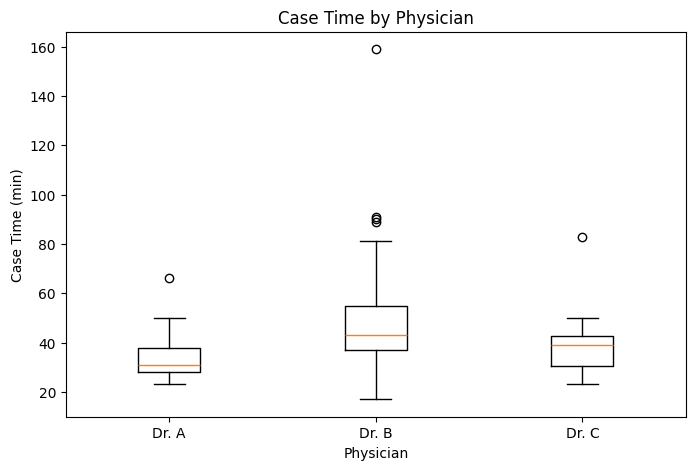

In [34]:
physicians = sorted(df["PHYSICIAN"].dropna().unique())
box_data = [df.loc[df["PHYSICIAN"] == p, CASE_TIME].dropna() for p in physicians]

plt.figure(figsize=(8, 5))
plt.boxplot(box_data, tick_labels=physicians)
plt.xlabel("Physician")
plt.ylabel("Case Time (min)")
plt.title("Case Time by Physician")
plt.show()


### Interpretation

Use this section after running the code:
- Identify which physician is fastest on average
- Identify which physician is most consistent
- Use the ANOVA result to comment on whether physician differences are statistically significant


## 6. Drivers of Variability

Examine which procedural stages are most associated with total case time.


In [35]:
correlation_cols = [
    CASE_TIME,
    "PT PREP/INTUBATION Pt-In-Access",
    "ACCESSS (Min)",
    "TSP (Min)",
    "PRE-MAP (Min)",
    "ABL DURATION (Abl Start-End)",
    "ABL TIME (Min)",
    "#ABL",
    "#APPLICATIONS 3/Abl",
    "LA DWELL TIME (Abl Start-Cath-Out)",
    "POST CARE/EXTUBATION (Cath-Out to Pt-Out)"
]

corr_with_case = (
    df[correlation_cols]
    .corr(numeric_only=True)[CASE_TIME]
    .sort_values(ascending=False)
)

display(corr_with_case.to_frame("correlation_with_case_time"))


,correlation_with_case_time
CASE TIME (Cath In-Out),1.000000
LA DWELL TIME (Abl Start-Cath-Out),0.792789
ABL DURATION (Abl Start-End),0.761600
TSP (Min),0.495266
PT PREP/INTUBATION Pt-In-Access,0.381229
#ABL,0.378575
#APPLICATIONS 3/Abl,0.377238
ABL TIME (Min),0.358174
PRE-MAP (Min),0.274981
POST CARE/EXTUBATION (Cath-Out to Pt-Out),0.271173


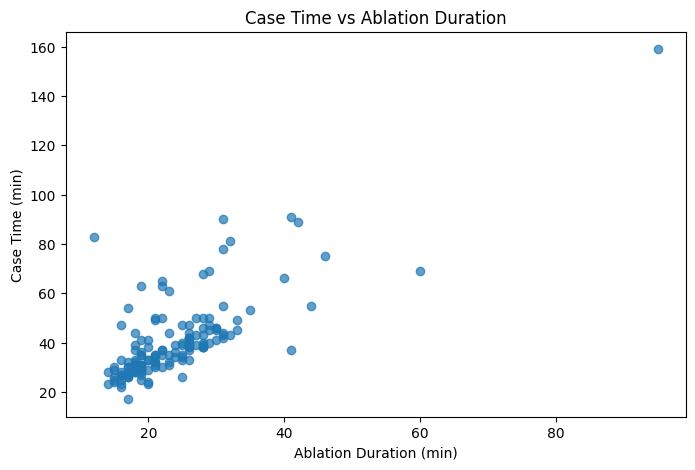

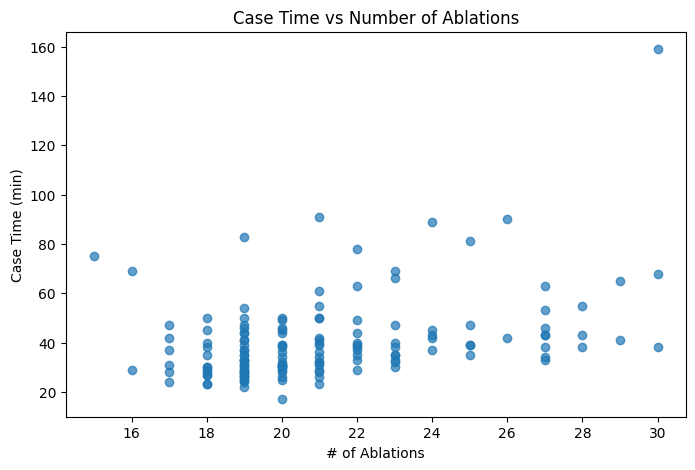

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(df["ABL DURATION (Abl Start-End)"], df[CASE_TIME], alpha=0.7)
plt.xlabel("Ablation Duration (min)")
plt.ylabel("Case Time (min)")
plt.title("Case Time vs Ablation Duration")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["#ABL"], df[CASE_TIME], alpha=0.7)
plt.xlabel("# of Ablations")
plt.ylabel("Case Time (min)")
plt.title("Case Time vs Number of Ablations")
plt.show()


### Interpretation

Use this section after running the code:
- Identify the strongest correlation with case time
- Explain whether ablation duration appears to be the main driver
- Comment on whether number of ablations also contributes


## 7. Case Complexity Effects

Use the **Note** column to compare standard vs more complex cases.


In [37]:
complexity_summary = (
    df.groupby("complex_case")[CASE_TIME]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

complexity_summary.index = ["Standard", "Complex"]
display(complexity_summary)


,count,mean,median,std
Standard,122,38.04,35.0,12.91
Complex,23,55.00,43.0,28.43


In [38]:
standard_cases = df.loc[df["complex_case"] == False, CASE_TIME].dropna()
complex_cases = df.loc[df["complex_case"] == True, CASE_TIME].dropna()

t_result = stats.ttest_ind(standard_cases, complex_cases, equal_var=False)

print("T-test: standard vs complex cases")
print(f"T-statistic = {t_result.statistic:.4f}")
print(f"p-value = {t_result.pvalue:.6f}")


T-test: standard vs complex cases
T-statistic = -2.8067
p-value = 0.009836


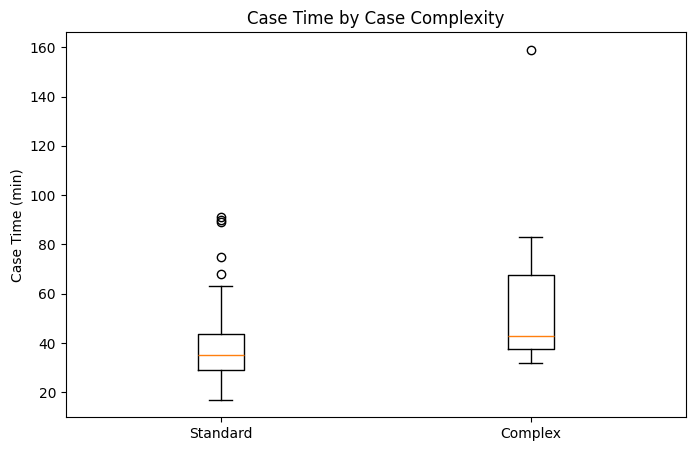

In [39]:
plt.figure(figsize=(8, 5))
plt.boxplot([standard_cases, complex_cases], tick_labels=["Standard", "Complex"])
plt.ylabel("Case Time (min)")
plt.title("Case Time by Case Complexity")
plt.show()


### Interpretation

Use this section after running the code:
- Compare the average case time of standard vs complex cases
- State whether complexity meaningfully affects procedure duration
- Use the t-test result to comment on statistical significance


## 8. Optional Learning Curve Check

This looks at whether case times change over sequential cases.


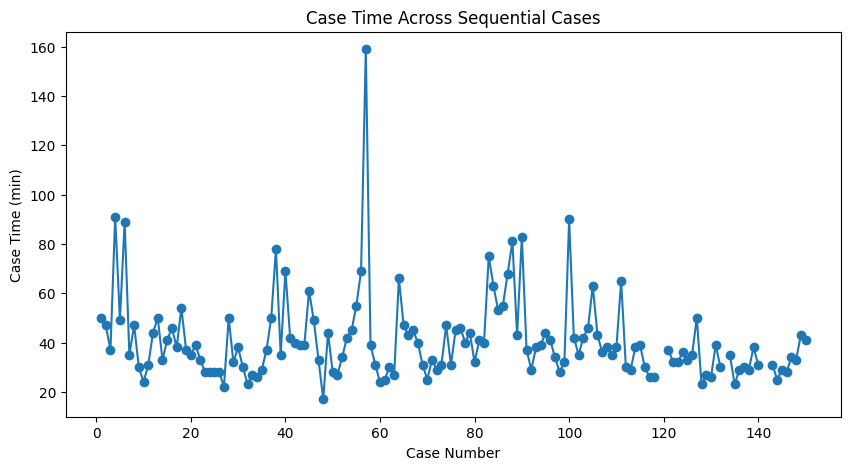

Correlation between CASE # and CASE TIME: -0.1477


In [40]:
df_sorted = df.sort_values("CASE #")

plt.figure(figsize=(10, 5))
plt.plot(df_sorted["CASE #"], df_sorted[CASE_TIME], marker="o", linestyle="-")
plt.xlabel("Case Number")
plt.ylabel("Case Time (min)")
plt.title("Case Time Across Sequential Cases")
plt.show()

learning_corr = df[["CASE #", CASE_TIME]].corr().iloc[0, 1]
print(f"Correlation between CASE # and CASE TIME: {learning_corr:.4f}")


# Phase 2 — Modeling and Validation

This phase builds a model to explain **CASE TIME** and tests whether the observed variables help predict it.

Important note:
- The target is **CASE TIME**
- Avoid using variables that are too close to the target if they create leakage
- The model is meant to explain patterns, not provide clinical recommendations


## 9. Prepare Modeling Dataset


In [41]:
model_df = df.copy()

target = CASE_TIME

features = [
    "PHYSICIAN",
    "PT PREP/INTUBATION Pt-In-Access",
    "ACCESSS (Min)",
    "TSP (Min)",
    "PRE-MAP (Min)",
    "ABL DURATION (Abl Start-End)",
    "ABL TIME (Min)",
    "#ABL",
    "complex_case"
]

model_df = model_df[features + [target]].dropna(subset=[target]).copy()

X = model_df[features]
y = model_df[target]

print("Modeling dataset shape:", model_df.shape)
display(model_df.head())


Modeling dataset shape: (145, 10)


,PHYSICIAN,PT PREP/INTUBATION Pt-In-Access,ACCESSS (Min),TSP (Min),PRE-MAP (Min),ABL DURATION (Abl Start-End),ABL TIME (Min),#ABL,complex_case,CASE TIME (Cath In-Out)
4,Dr. A,19.0,6.0,10.0,2.0,28.0,7.35,21.0,False,50.0
5,Dr. A,24.0,3.0,7.0,2.0,25.0,6.65,19.0,False,47.0
6,Dr. A,22.0,5.0,12.0,2.0,41.0,8.40,24.0,False,37.0
7,Dr. B,48.0,5.0,37.0,2.0,41.0,7.35,21.0,False,91.0
8,Dr. B,25.0,5.0,16.0,2.0,33.0,7.70,22.0,False,49.0


## 10. Train/Test Regression Model

A simple linear regression is used because it is interpretable and appropriate for explaining which factors are associated with longer case times.


In [42]:
numeric_features = [
    "PT PREP/INTUBATION Pt-In-Access",
    "ACCESSS (Min)",
    "TSP (Min)",
    "PRE-MAP (Min)",
    "ABL DURATION (Abl Start-End)",
    "ABL TIME (Min)",
    "#ABL"
]

categorical_features = ["PHYSICIAN", "complex_case"]

# Make a clean copy
X_model = X.copy()

# Force categorical columns to string type
for col in categorical_features:
    X_model[col] = X_model[col].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R^2  = {r2:.3f}")

MAE  = 4.96
RMSE = 6.49
R^2  = 0.604


### Interpretation

Use this section after running the code:
- MAE shows the average prediction error in minutes
- RMSE penalizes larger errors more heavily
- R² shows how much variation in case time is explained by the model


## 11. Cross-Validation

This checks whether the model performs consistently across different splits of the data.


In [43]:
# Use the same cleaned feature set used in Cell 10
cv_scores = cross_val_score(
    reg_model,
    X_model,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validated R^2 scores:", cv_scores)
print("Average CV R^2:", cv_scores.mean())

Cross-validated R^2 scores: [ 0.76362319  0.6716559  -0.34535186  0.16557128 -0.69636256]
Average CV R^2: 0.11182719124443788


## 12. OLS Regression for Interpretation

This version gives coefficients and p-values to help explain which variables are statistically associated with case time.


In [44]:
ols_df = model_df.copy()

ols_formula = """
Q("CASE TIME (Cath In-Out)") ~ 
C(PHYSICIAN) + 
Q("PT PREP/INTUBATION Pt-In-Access") +
Q("ACCESSS (Min)") +
Q("TSP (Min)") +
Q("PRE-MAP (Min)") +
Q("ABL DURATION (Abl Start-End)") +
Q("ABL TIME (Min)") +
Q("#ABL") +
complex_case
"""

ols_model = smf.ols(ols_formula, data=ols_df).fit()
print(ols_model.summary())


                                 OLS Regression Results                                 
Dep. Variable:     Q("CASE TIME (Cath In-Out)")   R-squared:                       0.714
Model:                                      OLS   Adj. R-squared:                  0.692
Method:                           Least Squares   F-statistic:                     33.41
Date:                          Thu, 19 Mar 2026   Prob (F-statistic):           1.03e-31
Time:                                  16:34:29   Log-Likelihood:                -528.62
No. Observations:                           145   AIC:                             1079.
Df Residuals:                               134   BIC:                             1112.
Df Model:                                    10                                         
Covariance Type:                      nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----

### Interpretation

Use this section after running the code:
- Look for variables with low p-values
- Check whether physician indicators remain important after controlling for other variables
- Check whether complexity still matters after accounting for procedural stages


## 13. Predicted vs Actual Values


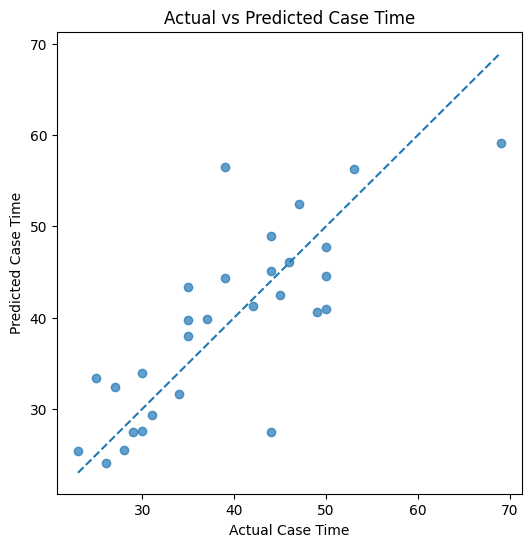

In [45]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Case Time")
plt.ylabel("Predicted Case Time")
plt.title("Actual vs Predicted Case Time")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()


## 14. Residual Diagnostics


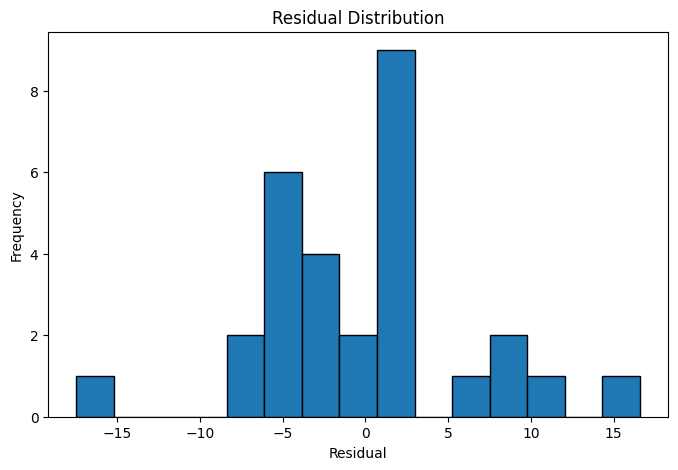

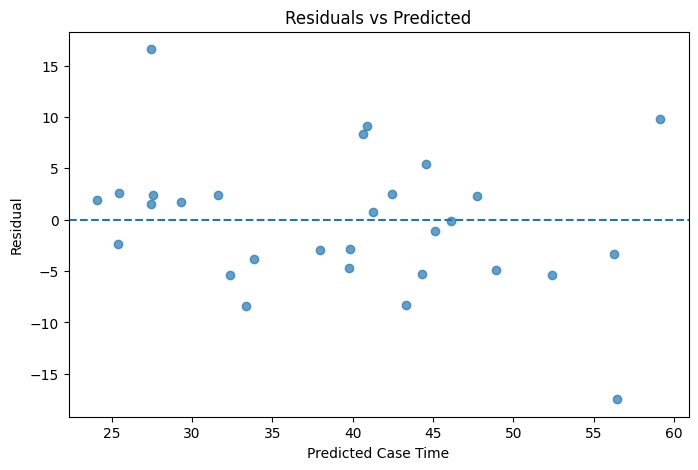

In [46]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=15, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Case Time")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()


## 15. Final Summary

After running the notebook, summarize your findings here. A strong final summary will likely cover:

- overall variability in case time
- whether physician differences are statistically meaningful
- whether ablation duration is the strongest driver
- whether complex cases are significantly longer
- how well the regression model explains case time
- what remains unexplained by the current dataset


## 16. Export of Tables and Figures




In [47]:
# Example exports:
physician_summary.to_csv("../outputs/physician_summary.csv")
corr_with_case.to_csv("../outputs/correlation_with_case_time.csv")
complexity_summary.to_csv("../outputs/complexity_summary.csv")
plt.figure(figsize=(8,5))
plt.hist(df[CASE_TIME].dropna(), bins=20, edgecolor="black")
plt.xlabel("Case Time (min)")
plt.ylabel("Frequency")
plt.title("Distribution of Case Time")
plt.savefig("../outputs/case_time_histogram.png", bbox_inches="tight")
plt.close()
